# Compare hue sensor data across conditions

Loads every condition in a session and compares a chosen feature (e.g. `distance`, `meanHueR`) across all or a subset of conditions, plus compares baseline channel means across conditions.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.hue.io import load_condition_set
from src.hue.analysis import compute_baseline, summarize_conditions
from src.hue.plotting import plot_feature_across_conditions, plot_baseline_comparison

## 1. Load all conditions and compute summaries/baselines

In [2]:
session_dir = repo_root / "data" / "hue" / "raw" / "data_17JUN26"
sessions = load_condition_set(session_dir)

summaries = summarize_conditions(sessions)
baselines = {condition: compute_baseline(df) for condition, df in sessions.items()}
sorted(sessions)

['G', 'GY', 'R', 'RG', 'RGY', 'RY']

## 2. Compare a feature across conditions

Pick any column from a per-condition summary (e.g. `distance`, `meanHueR`, `deltaG`) and either all conditions or a chosen subset.

<Axes: xlabel='trCnt', ylabel='distance'>

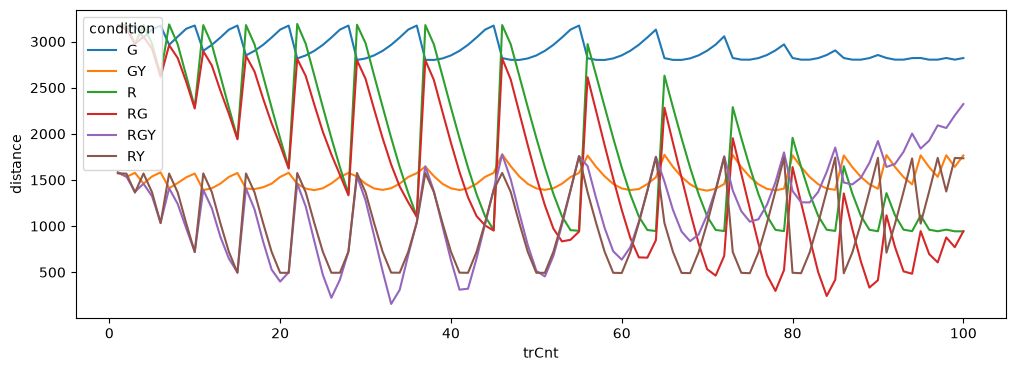

In [3]:
plot_feature_across_conditions(summaries, feature="distance")

<Axes: xlabel='trCnt', ylabel='meanHueR'>

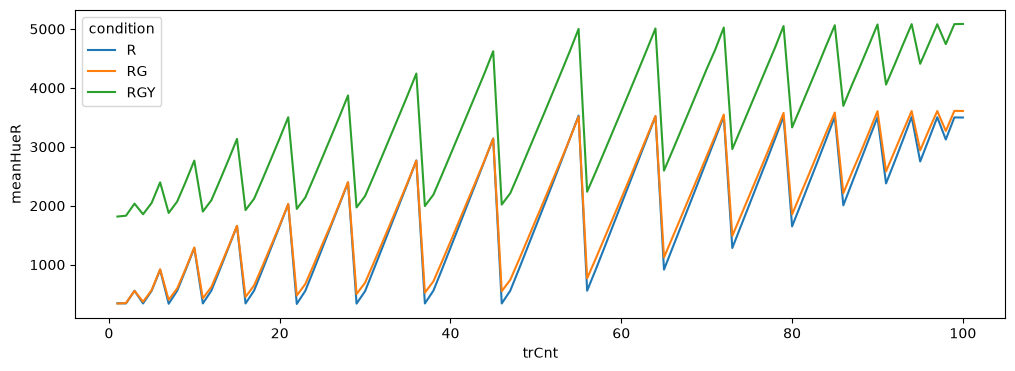

In [4]:
plot_feature_across_conditions(summaries, feature="meanHueR", conditions=["R", "RG", "RGY"])

## 3. Compare baselines across conditions

<Axes: xlabel='condition', ylabel='baseline mean raw count'>

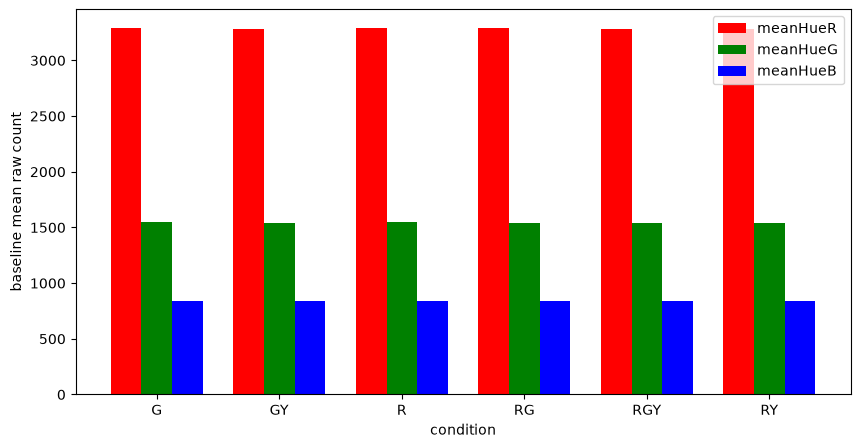

In [5]:
plot_baseline_comparison(baselines)

<Axes: xlabel='condition', ylabel='baseline mean raw count'>

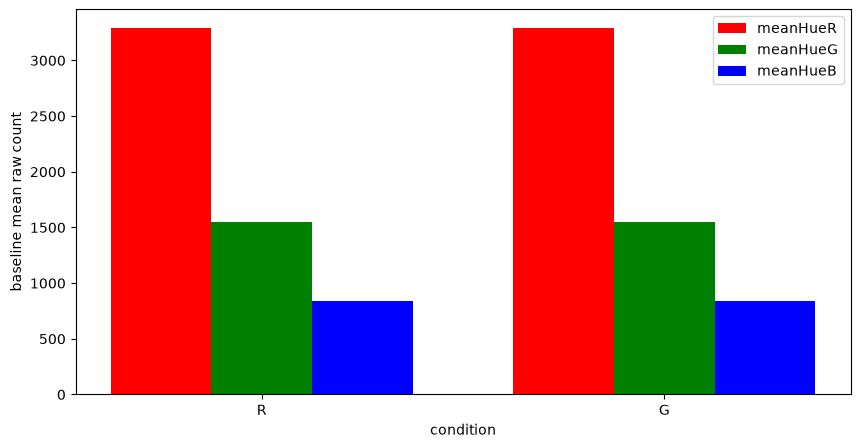

In [6]:
plot_baseline_comparison(baselines, conditions=["R", "G"])